In [1]:
import numpy as np
import pandas as pd

from rdkit import Chem, DataStructs
from rdkit.Chem import (
    PandasTools,
    Draw,
    Descriptors,
    MACCSkeys,
    rdFingerprintGenerator,
    rdMolDescriptors
)

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['axes.unicode_minus'] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
molecules  = pd.read_csv(r"E:\Projects\Mycobacterium tuberculosis\02-Generate Standard Smile\Valid_12756.csv")

In [3]:
molecules.head(1)

,Molecule ChEMBL ID,MIC,Units,Smiles,Label
0,CHEMBL1086385,0.12,ug.mL-1,CCCCCCCC[C@@H](C)C(=O)N1CCC[C@H]1C(=O)N[C@@H](...,1


Add their ROMol objects

In [4]:
PandasTools.AddMoleculeColumnToFrame(molecules, smilesCol="Smiles")

In [5]:
molecules.head(1)

,Molecule ChEMBL ID,MIC,Units,Smiles,Label,ROMol
0,CHEMBL1086385,0.12,ug.mL-1,CCCCCCCC[C@@H](C)C(=O)N1CCC[C@H]1C(=O)N[C@@H](...,1,<rdkit.Chem.rdchem.Mol object at 0x000002770F8...


Calculate molecular fingerprints

In [6]:
molecules["maccs"] = molecules.ROMol.apply(lambda m: MACCSkeys.GenMACCSKeys(m))

In [7]:
maccs_df = pd.DataFrame([list(i.ToBitString()[1:]) for i in molecules["maccs"]], columns=[f"MACCS_{i}" for i in range(166)])
molecules_maccs = pd.concat([molecules.iloc[:,:5], maccs_df], axis=1)

In [8]:
molecules_maccs.to_csv(r"E:\Projects\Mycobacterium tuberculosis\02-Generate Standard Smile\molecules_maccs.csv",index=False)

In [9]:
molecules.head()

,Molecule ChEMBL ID,MIC,Units,Smiles,Label,ROMol,maccs
0,CHEMBL1086385,0.120,ug.mL-1,CCCCCCCC[C@@H](C)C(=O)N1CCC[C@H]1C(=O)N[C@@H](...,1,<rdkit.Chem.rdchem.Mol object at 0x000002770F8...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
1,CHEMBL1086383,2.000,ug.mL-1,CCCCCCCC[C@@H](C)C(=O)N1CCC[C@H]1C(=O)N[C@@H](...,1,<rdkit.Chem.rdchem.Mol object at 0x000002770F8...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
2,CHEMBL225164,0.125,ug.mL-1,Oc1ccc(Cl)c2cccnc12,1,<rdkit.Chem.rdchem.Mol object at 0x000002770F8...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
3,CHEMBL497,6.250,ug.mL-1,Oc1c(I)cc(Cl)c2cccnc12,1,<rdkit.Chem.rdchem.Mol object at 0x000002770F8...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
4,CHEMBL4061841,25.000,ug.mL-1,NC(=O)C1CCN(Cc2c(-c3ccccc3)[nH]c3ccnc(Cl)c23)CC1,0,<rdkit.Chem.rdchem.Mol object at 0x000002770F8...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [10]:
n = len(molecules['maccs'])
print(n)

12756


In [11]:
tanimoto_matrix = np.zeros((n, n))

In [12]:
for i in range(n):
    tanimoto_matrix[i, :] = DataStructs.BulkTanimotoSimilarity(molecules['maccs'][i], molecules['maccs'])

In [13]:
tanimoto_matrix

array([[1.        , 0.96666667, 0.13513514, ..., 0.30379747, 0.5375    ,
        0.55696203],
       [0.96666667, 1.        , 0.13513514, ..., 0.30379747, 0.51851852,
        0.5375    ],
       [0.13513514, 0.13513514, 1.        , ..., 0.30188679, 0.17105263,
        0.17105263],
       ...,
       [0.30379747, 0.30379747, 0.30188679, ..., 1.        , 0.28571429,
        0.24137931],
       [0.5375    , 0.51851852, 0.17105263, ..., 0.28571429, 1.        ,
        0.91044776],
       [0.55696203, 0.5375    , 0.17105263, ..., 0.24137931, 0.91044776,
        1.        ]])

In [14]:
tanimoto_matrix.shape

(12756, 12756)

In [17]:
np.save('tanimoto_matrix.npy', tanimoto_matrix)

In [20]:
upper_triangle = tanimoto_matrix[np.triu_indices(n, k=1)] # n(n-1)/2

In [22]:
upper_triangle.shape

(81351390,)

In [31]:
print(f'len:{len(upper_triangle)}')
print('Mean:',np.mean(upper_triangle))
print('Max:',np.max(upper_triangle))
print('Min:',np.min(upper_triangle))
print('Median:',np.median(upper_triangle))

count_leq = len([x for x in upper_triangle if x <= 0.4])
proportion = count_leq / len(upper_triangle)
print(f'proportion of less than 0.4:{proportion}')

len:81351390
Mean: 0.3640694064789452
Max: 1.0
Min: 0.0
Median: 0.36231884057971014
proportion of less than 0.4:0.618556388526367


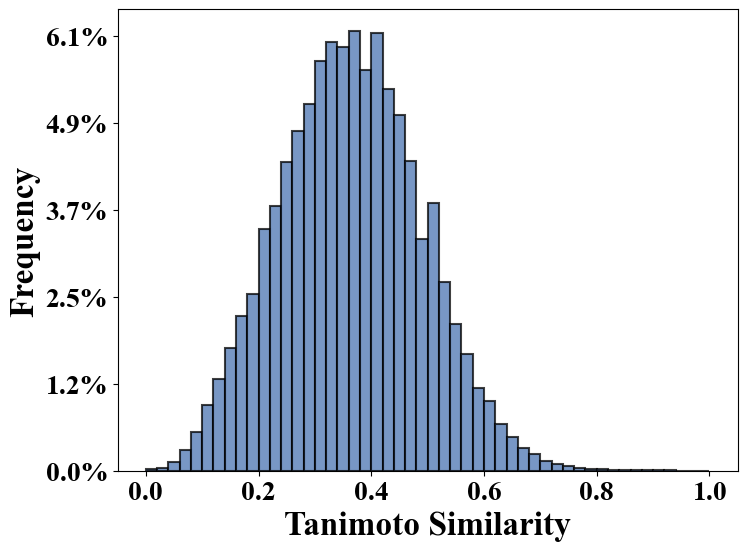

In [40]:
fig, ax = plt.subplots(figsize=(8, 6))

n, bins, patches = ax.hist(upper_triangle, 
                           bins=50, 
                           color="#4B74B2", 
                           edgecolor="black", 
                           alpha=0.75, 
                           linewidth=1.5)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y / len(upper_triangle) * 100:.1f}%"))

ax.set_xlabel("Tanimoto Similarity",fontsize=24, fontweight='bold')
ax.set_ylabel("Frequency",fontsize=24, fontweight='bold')

plt.xticks(fontsize=20, weight='bold')
plt.yticks(fontsize=20, weight='bold')

ax.set_title('')

plt.savefig("MACCS_Simility.pdf", format='pdf', bbox_inches='tight')

plt.show()